In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the SMS Spam Collection dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "message"])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape: (5572, 2)

Column data types:
label      str
message    str
dtype: object

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


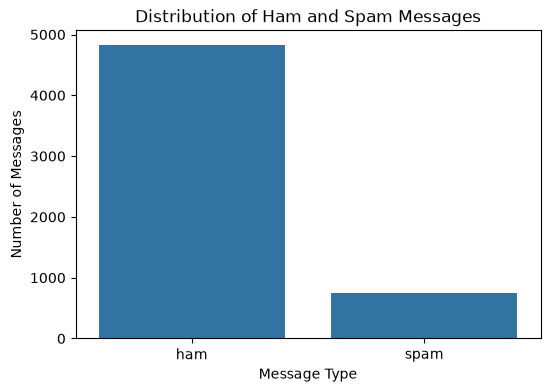

In [4]:
# Visualize the number of ham and spam messages
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [5]:
# Convert labels into numerical values
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [6]:
# Separate messages and labels
X = df["message"]
y = df["label_num"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [7]:
# Convert text messages into TF-IDF features
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (4457, 5000)
Testing feature shape: (1115, 5000)


In [8]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully.")


Model training completed successfully.


In [9]:
# Make predictions on the test data
y_pred = model.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9704035874439462
Accuracy Percentage: 97.04035874439462 %


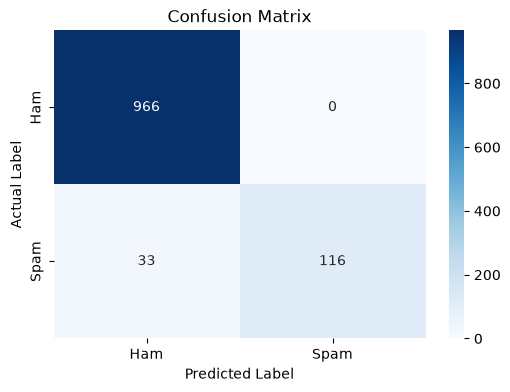

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

In [11]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)
print("Naive Bayes Accuracy Percentage:", accuracy_nb * 100, "%")

Naive Bayes Accuracy: 0.9721973094170404
Naive Bayes Accuracy Percentage: 97.21973094170404 %


In [12]:
# Compare model performance

print("Model Comparison")
print("=================")

print("Logistic Regression Accuracy:", accuracy * 100, "%")
print("Naive Bayes Accuracy:", accuracy_nb * 100, "%")

if accuracy_nb > accuracy:
    print("\nNaive Bayes performed better based on accuracy.")
else:
    print("\nLogistic Regression performed better based on accuracy.")

Model Comparison
Logistic Regression Accuracy: 97.04035874439462 %
Naive Bayes Accuracy: 97.21973094170404 %

Naive Bayes performed better based on accuracy.


## Conclusion

This project uses machine learning to detect whether an SMS message is ham or spam. The SMS messages were converted into numerical TF-IDF features so that machine learning models could process the text.

Two classification models were used: Logistic Regression and Multinomial Naive Bayes. Logistic Regression achieved an accuracy of approximately 97.04%, while Naive Bayes achieved approximately 97.22% on the test data.

Based on the accuracy obtained on this test split, Naive Bayes performed slightly better than Logistic Regression.

The confusion matrix and classification report were also used to evaluate the classification performance using precision, recall, and F1-score.